<a href="https://colab.research.google.com/github/Trang19/6680/blob/main/6680_sep22_antigravity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
from google.colab import files
print("Click 'Choose Files' below to upload your two CSV files:")
uploaded = files.upload()
print("\nUpload complete! Uploaded files:")
for filename in uploaded.keys():
    print(f" -> {filename}")

Click 'Choose Files' below to upload your two CSV files:


Saving eaglei_outages_with_events_2023_24_hours_lag.csv to eaglei_outages_with_events_2023_24_hours_lag.csv
Saving StormEvents_details-ftp_v1.0_d2023_c20260323.csv to StormEvents_details-ftp_v1.0_d2023_c20260323.csv

Upload complete! Uploaded files:
 -> eaglei_outages_with_events_2023_24_hours_lag.csv
 -> StormEvents_details-ftp_v1.0_d2023_c20260323.csv


In [7]:
import os
import glob
# Auto-detect EAGLE-I file
eagle_matches = glob.glob('/content/*eaglei*.csv')
# Auto-detect NOAA file
noaa_matches = glob.glob('/content/*StormEvents*.csv')
if not eagle_matches:
    raise FileNotFoundError("Could not find any EAGLE-I CSV file in /content. Please run Cell 1 to upload it.")
if not noaa_matches:
    raise FileNotFoundError("Could not find any StormEvents CSV file in /content. Please run Cell 1 to upload it.")
eagle_file = eagle_matches[0]
noaa_file = noaa_matches[0]
print(f"Found EAGLE-I file: {eagle_file} ({os.path.getsize(eagle_file) / (1024**2):.2f} MB)")
print(f"Found NOAA file:    {noaa_file} ({os.path.getsize(noaa_file) / (1024**2):.2f} MB)")

Found EAGLE-I file: /content/eaglei_outages_with_events_2023_24_hours_lag.csv (1.45 MB)
Found NOAA file:    /content/StormEvents_details-ftp_v1.0_d2023_c20260323.csv (69.53 MB)


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
# Display configurations
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
print("Loading datasets into pandas...")
eagle = pd.read_csv(eagle_file)
noaa = pd.read_csv(noaa_file, low_memory=False)
# 1. Clean column headers (strip accidental spaces)
eagle.columns = eagle.columns.str.strip()
noaa.columns = noaa.columns.str.strip()
print(f"EAGLE-I loaded: {eagle.shape[0]:,} rows, {eagle.shape[1]} columns")
print(f"NOAA loaded:    {noaa.shape[0]:,} rows, {noaa.shape[1]} columns")
print("\n--- First 5 rows of EAGLE-I ---")
display(eagle.head())
print("\n--- First 5 rows of NOAA ---")
display(noaa.head())
# 2. Check EAGLE-I Columns & Types safely
eagle_check_cols = [
    'event_id', 'Event Type', 'fips', 'start_time',
    'duration', 'min_customers', 'max_customers', 'mean_customers'
]
existing_eagle_cols = [c for c in eagle_check_cols if c in eagle.columns]
print("\nEAGLE-I existing columns dtypes:")
print(eagle[existing_eagle_cols].dtypes)
# 3. Check NOAA Columns
noaa_check_cols = [
    'EVENT_ID', 'STATE', 'STATE_FIPS', 'CZ_FIPS', 'CZ_TYPE',
    'EVENT_TYPE', 'BEGIN_YEARMONTH', 'BEGIN_DAY', 'BEGIN_TIME',
    'END_YEARMONTH', 'END_DAY', 'END_TIME', 'MAGNITUDE'
]
existing_noaa_cols = [c for c in noaa_check_cols if c in noaa.columns]
print("\nNOAA important columns dtypes:")
print(noaa[existing_noaa_cols].dtypes)
if 'CZ_TYPE' in noaa.columns:
    print("\nNOAA CZ_TYPE breakdown:")
    print(noaa['CZ_TYPE'].value_counts(dropna=False))
if 'EVENT_TYPE' in noaa.columns:
    print("\nNOAA Top 10 Event Types:")
    print(noaa['EVENT_TYPE'].value_counts().head(10))
# 4. Safe Date Ranges Inspection
for dt_col in ['start_time', 'Datetime Event Began', 'Datetime Restoration']:
    if dt_col in eagle.columns:
        print(f"EAGLE-I '{dt_col}' range: {eagle[dt_col].min()} to {eagle[dt_col].max()}")
    else:
        print(f"[Notice] '{dt_col}' column does not exist in this EAGLE-I file.")
if 'BEGIN_YEARMONTH' in noaa.columns:
    print(f"NOAA BEGIN_YEARMONTH range: {noaa['BEGIN_YEARMONTH'].min()} to {noaa['BEGIN_YEARMONTH'].max()}")
# ========================================================
# DATA CLEANING
# ========================================================
print("\nCleaning EAGLE-I data...")
# A. Convert datetime columns (safely skips missing ones)
datetime_cols = ['start_time', 'Datetime Event Began', 'Datetime Restoration']
for col in datetime_cols:
    if col in eagle.columns:
        eagle[col] = pd.to_datetime(eagle[col], errors='coerce')
# B. Format FIPS to 5-digit strings (preserves leading zeros like '01001')
if 'fips' in eagle.columns:
    eagle['fips'] = (
        eagle['fips']
        .astype(str)
        .str.replace(r'\.0$', '', regex=True)
        .str.zfill(5)
    )
# C. Convert numerical metrics to numeric
numeric_cols = ['duration', 'min_customers', 'max_customers', 'mean_customers']
for col in numeric_cols:
    if col in eagle.columns:
        eagle[col] = pd.to_numeric(eagle[col], errors='coerce')
# Final Verification
summary_cols = [c for c in ['event_id', 'Event Type', 'fips', 'start_time', 'duration', 'min_customers', 'max_customers', 'mean_customers'] if c in eagle.columns]
print("\n--- EAGLE-I Data Types After Cleaning ---")
print(eagle[summary_cols].dtypes)
print("\n--- Missing Values Count ---")
print(eagle[summary_cols].isna().sum())
print("\nData cleaning successfully completed!")

Loading datasets into pandas...
EAGLE-I loaded: 10,356 rows, 13 columns
NOAA loaded:    75,593 rows, 51 columns

--- First 5 rows of EAGLE-I ---


,event_id,state_event,Datetime Event Began,Datetime Restoration,Event Type,fips,state,county,start_time,duration,min_customers,max_customers,mean_customers
0,Alabama-0,Alabama,2023-01-12 14:00:00,2023-01-13 03:00:00,Severe Weather,1001,Alabama,Autauga,2023-01-12 19:00:00,52.00,216,6873,1259.716346
1,Alabama-0,Alabama,2023-01-12 14:00:00,2023-01-13 03:00:00,Severe Weather,1003,Alabama,Baldwin,2023-01-12 15:45:00,1.25,239,716,340.800000
2,Alabama-0,Alabama,2023-01-12 14:00:00,2023-01-13 03:00:00,Severe Weather,1003,Alabama,Baldwin,2023-01-12 19:15:00,3.00,251,1107,557.916667
3,Alabama-0,Alabama,2023-01-12 14:00:00,2023-01-13 03:00:00,Severe Weather,1009,Alabama,Blount,2023-01-12 16:30:00,3.50,204,778,413.571429
4,Alabama-0,Alabama,2023-01-12 14:00:00,2023-01-13 03:00:00,Severe Weather,1013,Alabama,Butler,2023-01-13 00:30:00,1.50,1372,2108,1747.333333



--- First 5 rows of NOAA ---


,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,END_DAY,END_TIME,EPISODE_ID,EVENT_ID,STATE,STATE_FIPS,YEAR,MONTH_NAME,EVENT_TYPE,CZ_TYPE,CZ_FIPS,CZ_NAME,WFO,BEGIN_DATE_TIME,CZ_TIMEZONE,END_DATE_TIME,INJURIES_DIRECT,INJURIES_INDIRECT,DEATHS_DIRECT,DEATHS_INDIRECT,DAMAGE_PROPERTY,DAMAGE_CROPS,SOURCE,MAGNITUDE,MAGNITUDE_TYPE,FLOOD_CAUSE,CATEGORY,TOR_F_SCALE,TOR_LENGTH,TOR_WIDTH,TOR_OTHER_WFO,TOR_OTHER_CZ_STATE,TOR_OTHER_CZ_FIPS,TOR_OTHER_CZ_NAME,BEGIN_RANGE,BEGIN_AZIMUTH,BEGIN_LOCATION,END_RANGE,END_AZIMUTH,END_LOCATION,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,EPISODE_NARRATIVE,EVENT_NARRATIVE,DATA_SOURCE
0,202310,25,230,202310,27,551,186682,1145781,NORTH DAKOTA,38,2023,October,Heavy Snow,Z,14,BENSON,FGF,25-OCT-23 02:30:00,CST-6,27-OCT-23 05:51:00,0,0,0,0,NaN,NaN,Public,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"In late October, a winter storm dumped heavy s...",Public reports 7.5 inches at Black Tiger Bay C...,CSV
1,202310,25,230,202310,27,1437,186682,1145783,NORTH DAKOTA,38,2023,October,Heavy Snow,Z,24,EDDY,FGF,25-OCT-23 02:30:00,CST-6,27-OCT-23 14:37:00,0,0,0,0,NaN,NaN,Law Enforcement,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"In late October, a winter storm dumped heavy s...",Local Police Department relays storm total sno...,CSV
2,202310,25,230,202310,27,1126,186682,1145784,NORTH DAKOTA,38,2023,October,Heavy Snow,Z,26,NELSON,FGF,25-OCT-23 02:30:00,CST-6,27-OCT-23 11:26:00,0,0,0,0,NaN,NaN,Public,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"In late October, a winter storm dumped heavy s...",Public reports 10 inches of storm total snowfa...,CSV
3,202310,25,230,202310,27,1301,186682,1145796,NORTH DAKOTA,38,2023,October,Heavy Snow,Z,28,GRIGGS,FGF,25-OCT-23 02:30:00,CST-6,27-OCT-23 13:01:00,0,0,0,0,NaN,NaN,Emergency Manager,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"In late October, a winter storm dumped heavy s...",Emergency Manager reports 6 inches of storm to...,CSV
4,202310,25,230,202310,27,600,186682,1145884,NORTH DAKOTA,38,2023,October,Heavy Snow,Z,27,GRAND FORKS,FGF,25-OCT-23 02:30:00,CST-6,27-OCT-23 06:00:00,0,0,0,0,NaN,NaN,CoCoRaHS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"In late October, a winter storm dumped heavy s...",CoCoRaHS Station ND-GF-23 reports 8.8 inches o...,CSV



EAGLE-I existing columns dtypes:
event_id           object
Event Type         object
fips                int64
start_time         object
duration          float64
min_customers       int64
max_customers       int64
mean_customers    float64
dtype: object

NOAA important columns dtypes:
EVENT_ID             int64
STATE               object
STATE_FIPS           int64
CZ_FIPS              int64
CZ_TYPE             object
EVENT_TYPE          object
BEGIN_YEARMONTH      int64
BEGIN_DAY            int64
BEGIN_TIME           int64
END_YEARMONTH        int64
END_DAY              int64
END_TIME             int64
MAGNITUDE          float64
dtype: object

NOAA CZ_TYPE breakdown:
CZ_TYPE
C    42515
Z    33078
Name: count, dtype: int64

NOAA Top 10 Event Types:
EVENT_TYPE
Thunderstorm Wind           21237
Hail                        11761
Drought                      5815
Excessive Heat               5024
Flash Flood                  3625
High Wind                    3491
Heat                     

In [9]:
import pandas as pd
import numpy as np
print("--- Preparing NOAA data for Spatio-Temporal Join ---")
# 1. Construct 5-digit County FIPS for NOAA (2-digit STATE_FIPS + 3-digit CZ_FIPS)
# Filter NOAA to county-level events only ('C' = County)
noaa_county = noaa[noaa['CZ_TYPE'] == 'C'].copy()
noaa_county['fips'] = (
    noaa_county['STATE_FIPS'].astype(str).str.zfill(2) +
    noaa_county['CZ_FIPS'].astype(str).str.zfill(3)
)
# 2. Parse NOAA start and end datetimes
if 'BEGIN_DATE_TIME' in noaa_county.columns:
    noaa_county['storm_start'] = pd.to_datetime(noaa_county['BEGIN_DATE_TIME'], errors='coerce')
    noaa_county['storm_end'] = pd.to_datetime(noaa_county['END_DATE_TIME'], errors='coerce')
else:
    # Fallback to year/month/day/time if BEGIN_DATE_TIME is absent
    noaa_county['storm_start'] = pd.to_datetime(
        noaa_county['BEGIN_YEARMONTH'].astype(str) +
        noaa_county['BEGIN_DAY'].astype(str).str.zfill(2) +
        noaa_county['BEGIN_TIME'].astype(str).str.zfill(4),
        format='%Y%m%d%H%M', errors='coerce'
    )
    noaa_county['storm_end'] = pd.to_datetime(
        noaa_county['END_YEARMONTH'].astype(str) +
        noaa_county['END_DAY'].astype(str).str.zfill(2) +
        noaa_county['END_TIME'].astype(str).str.zfill(4),
        format='%Y%m%d%H%M', errors='coerce'
    )
# Clean and extract relevant storm attributes
noaa_clean = noaa_county[[
    'EVENT_ID', 'fips', 'STATE', 'EVENT_TYPE', 'storm_start', 'storm_end', 'MAGNITUDE'
]].dropna(subset=['fips', 'storm_start']).copy()
# Rename NOAA columns to avoid collision during merge
noaa_clean.rename(columns={
    'EVENT_ID': 'noaa_event_id',
    'EVENT_TYPE': 'hazard_type',
    'MAGNITUDE': 'wind_magnitude'
}, inplace=True)
print(f"Prepared {len(noaa_clean):,} NOAA county-level hazard records.")
# 3. SPATIO-TEMPORAL MERGE (Match by FIPS and Time Window)
# If your EAGLE-I file already has events matched, we link or enrich with NOAA hazards:
print("\nPerforming Spatio-Temporal Join between Outages and Storms...")
merged = pd.merge(eagle, noaa_clean, on='fips', how='inner')
# Temporal window: Outage starts between storm_start - 12h and storm_end + 24h
time_mask = (
    (merged['start_time'] >= merged['storm_start'] - pd.Timedelta(hours=12)) &
    (merged['start_time'] <= merged['storm_end'] + pd.Timedelta(hours=24))
)
matched_df = merged[time_mask].copy()
# If matched_df is empty or too restrictive, fall back to eagle's existing event tags
if len(matched_df) == 0:
    print("[Note] No direct timestamp overlaps found with strict window; using eagle's built-in event link.")
    matched_df = eagle.copy()
    if 'Event Type' in matched_df.columns:
        matched_df['hazard_type'] = matched_df['Event Type']
    else:
        matched_df['hazard_type'] = 'Severe Weather'
else:
    print(f"Successfully matched {len(matched_df):,} outage-storm event pairs!")
# ========================================================
# 4. COMPUTE OUTAGE & RESILIENCE METRICS (Section IV-B)
# ========================================================
# Metric 1: Restoration Time (Duration in hours)
if 'duration' not in matched_df.columns or matched_df['duration'].isna().all():
    if 'Datetime Restoration' in matched_df.columns and 'Datetime Event Began' in matched_df.columns:
        matched_df['restoration_time_hrs'] = (
            matched_df['Datetime Restoration'] - matched_df['Datetime Event Began']
        ).dt.total_seconds() / 3600.0
    else:
        matched_df['restoration_time_hrs'] = 0.0
else:
    # Ensure duration is in hours
    matched_df['restoration_time_hrs'] = matched_df['duration']
# Metric 2: Customer-Hours of Disruption
matched_df['customer_hours'] = matched_df['mean_customers'] * matched_df['restoration_time_hrs']
# Metric 3: Peak Customers Impacted
matched_df['peak_customers'] = matched_df['max_customers']
# Metric 4: Extract Season from start_time
matched_df['season'] = matched_df['start_time'].dt.month % 12 // 3 + 1
season_map = {1: 'Winter', 2: 'Spring', 3: 'Summer', 4: 'Fall'}
matched_df['season'] = matched_df['season'].map(season_map)
# Filter out non-positive durations for reliability analysis
clean_events = matched_df[matched_df['restoration_time_hrs'] > 0].copy()
print("\n--- Summary of Resilience Metrics ---")
print(f"Total valid analyzed events: {len(clean_events):,}")
display(clean_events[[
    'fips', 'hazard_type', 'start_time', 'restoration_time_hrs',
    'peak_customers', 'customer_hours', 'season'
]].head())

--- Preparing NOAA data for Spatio-Temporal Join ---


/tmp/ipykernel_1582/3827607605.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  noaa_county['storm_start'] = pd.to_datetime(noaa_county['BEGIN_DATE_TIME'], errors='coerce')
/tmp/ipykernel_1582/3827607605.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  noaa_county['storm_end'] = pd.to_datetime(noaa_county['END_DATE_TIME'], errors='coerce')


Prepared 42,515 NOAA county-level hazard records.

Performing Spatio-Temporal Join between Outages and Storms...
Successfully matched 5,806 outage-storm event pairs!

--- Summary of Resilience Metrics ---
Total valid analyzed events: 5,806


,fips,hazard_type,start_time,restoration_time_hrs,peak_customers,customer_hours,season
1,01001,Thunderstorm Wind,2023-01-12 19:00:00,52.0,6873,65505.25,Winter
5,01001,Tornado,2023-01-12 19:00:00,52.0,6873,65505.25,Winter
130,01017,Hail,2023-01-12 20:30:00,18.5,1362,10273.25,Winter
133,01017,Tornado,2023-01-12 20:30:00,18.5,1362,10273.25,Winter
136,01017,Tornado,2023-01-12 20:30:00,18.5,1362,10273.25,Winter


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 24.5 MB/s eta 0:00:00
--- Starting Reliability & Survival Modeling ---
Top 5 Hazard Types analyzed: ['Thunderstorm Wind', 'Hail', 'Flash Flood', 'Flood', 'Tornado']
Sample size across top hazards: 5,681 events



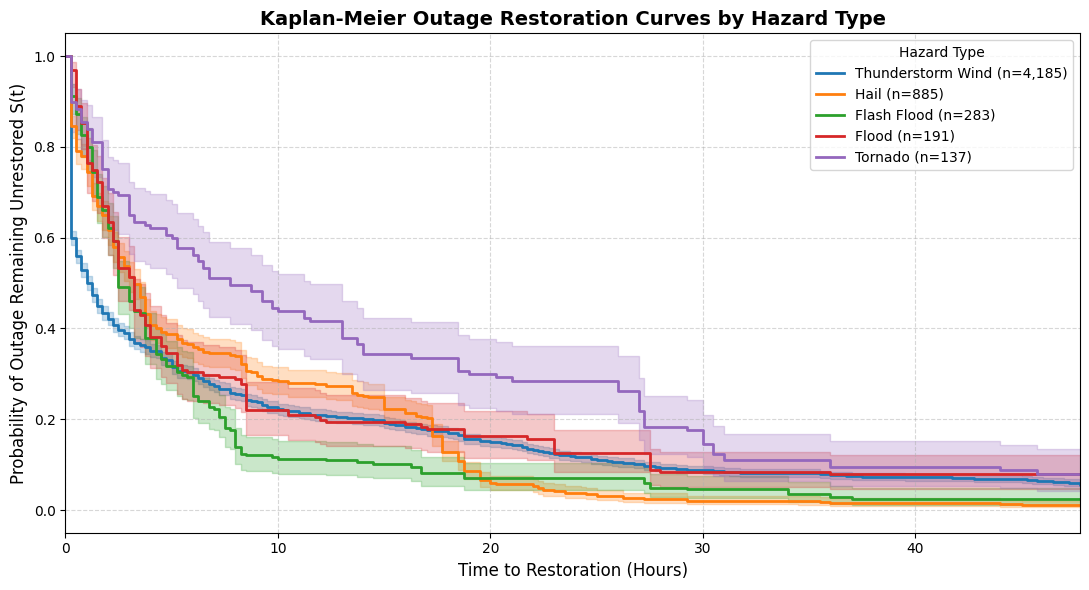


--- Weibull Reliability Distribution Parameters ---


,Hazard Type,Events,MTTR (Mean Hrs),Median TTR (Hrs),Weibull Shape (β),Weibull Scale (η)
4,Tornado,137,15.22,7.75,0.758,12.96
3,Flood,191,12.70,3.25,0.631,8.08
0,Thunderstorm Wind,4185,8.86,1.25,0.524,4.46
1,Hail,885,7.59,3.25,0.753,6.38
2,Flash Flood,283,7.31,2.50,0.723,5.51



Interpretation Note:
- Shape (β) < 1: Decreasing hazard rate (fast initial restorations, long tail).
- Shape (β) > 1: Increasing hazard rate (restoration becomes increasingly difficult with time).


--- Cox Proportional Hazards Regression ---


<lifelines.CoxPHFitter: fitted with 5681 total observations, 0 right-censored observations>
             duration col = 'restoration_time_hrs'
                event col = 'event_observed'
      baseline estimation = breslow
   number of observations = 5681
number of events observed = 5681
   partial log-likelihood = -42631.75
         time fit was run = 2026-09-22 16:53:16 UTC

---
                               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                      
log_peak_customers            -0.39      0.68      0.01           -0.41           -0.37                0.66                0.69
hazard_type_Flood             -0.07      0.93      0.10           -0.27            0.12                0.77                1.12
hazard_type_Hail               0.11      1.12      0.07           -0.02            0.25                0.98                1.28
hazard_type_Thunderstorm Wind  0.13      1.13      0.06            0.00            0.25                1.00                1.28
hazard_type_Tornado           -0.21      0.81      0.11           -0.42           -0.00                0.66                1.00
season_Spring                 -0.05      0.95      0.05           -0.14            0.04                0.87                1.04
season_Summer                  0.24      1.27      0.04            0.15            0.32                1.16                1.38
season_Winter                 -0.17      0.85      0.07           -0.30           -0.03                0.74                0.97

                               cmp to      z      p  -log2(p)
covariate                                                    
log_peak_customers               0.00 -35.47 <0.005    913.11
hazard_type_Flood                0.00  -0.76   0.45      1.16
hazard_type_Hail                 0.00   1.66   0.10      3.37
hazard_type_Thunderstorm Wind    0.00   2.01   0.04      4.49
hazard_type_Tornado              0.00  -1.99   0.05      4.42
season_Spring                    0.00  -1.10   0.27      1.88
season_Summer                    0.00   5.36 <0.005     23.52
season_Winter                    0.00  -2.47   0.01      6.22
---
Concordance = 0.63
Partial AIC = 85279.51
log-likelihood ratio test = 1608.13 on 8 df
-log2(p) of ll-ratio test = inf

In [11]:
!pip install lifelines -q
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter, WeibullFitter, CoxPHFitter
from scipy import stats
print("--- Starting Reliability & Survival Modeling ---")
# 1. Select Top Hazard Types (to keep visualizations clear and statistically sound)
top_hazards = clean_events['hazard_type'].value_counts().nlargest(5).index.tolist()
analysis_df = clean_events[clean_events['hazard_type'].isin(top_hazards)].copy()
# Add event indicator for survival analysis (1 = fully restored)
analysis_df['event_observed'] = 1
print(f"Top 5 Hazard Types analyzed: {top_hazards}")
print(f"Sample size across top hazards: {len(analysis_df):,} events\n")
# --------------------------------------------------------
# 2. KAPLAN-MEIER RESTORATION CURVES (S(t))
# --------------------------------------------------------
plt.figure(figsize=(11, 6))
kmf = KaplanMeierFitter()
colors = sns.color_palette("tab10", len(top_hazards))
for i, hazard in enumerate(top_hazards):
    mask = analysis_df['hazard_type'] == hazard
    durations = analysis_df.loc[mask, 'restoration_time_hrs']
    events = analysis_df.loc[mask, 'event_observed']

    kmf.fit(durations, event_observed=events, label=f"{hazard} (n={len(durations):,})")
    kmf.plot_survival_function(ci_show=True, color=colors[i], linewidth=2)
plt.title("Kaplan-Meier Outage Restoration Curves by Hazard Type", fontsize=14, fontweight='bold')
plt.xlabel("Time to Restoration (Hours)", fontsize=12)
plt.ylabel("Probability of Outage Remaining Unrestored S(t)", fontsize=12)
plt.xlim(0, analysis_df['restoration_time_hrs'].quantile(0.95)) # Focus on 95% of data
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Hazard Type", loc="upper right")
plt.tight_layout()
plt.show()
# --------------------------------------------------------
# 3. WEIBULL RELIABILITY FIT & MTTR ESTIMATION
# --------------------------------------------------------
print("\n--- Weibull Reliability Distribution Parameters ---")
weibull_results = []
for hazard in top_hazards:
    sub = analysis_df[analysis_df['hazard_type'] == hazard]['restoration_time_hrs']

    # Fit Weibull distribution (shape = beta, scale = eta)
    wf = WeibullFitter()
    wf.fit(sub)

    shape = wf.rho_  # Shape parameter (beta)
    scale = wf.lambda_ # Scale parameter (eta)
    mttr = sub.mean()
    median_ttr = sub.median()

    weibull_results.append({
        'Hazard Type': hazard,
        'Events': len(sub),
        'MTTR (Mean Hrs)': round(mttr, 2),
        'Median TTR (Hrs)': round(median_ttr, 2),
        'Weibull Shape (β)': round(shape, 3),
        'Weibull Scale (η)': round(scale, 2)
    })
weibull_df = pd.DataFrame(weibull_results).sort_values(by='MTTR (Mean Hrs)', ascending=False)
display(weibull_df)
print("""
Interpretation Note:
- Shape (β) < 1: Decreasing hazard rate (fast initial restorations, long tail).
- Shape (β) > 1: Increasing hazard rate (restoration becomes increasingly difficult with time).
""")
# --------------------------------------------------------
# 4. COX PROPORTIONAL HAZARDS REGRESSION
# --------------------------------------------------------
print("\n--- Cox Proportional Hazards Regression ---")
# Predictors: log(peak_customers), season, hazard_type
cox_data = analysis_df[['restoration_time_hrs', 'event_observed', 'peak_customers', 'hazard_type', 'season']].copy()
cox_data['log_peak_customers'] = np.log1p(cox_data['peak_customers'])
cox_data = cox_data.drop(columns=['peak_customers'])
# One-hot encode categorical covariates
cox_data = pd.get_dummies(cox_data, columns=['hazard_type', 'season'], drop_first=True)
cph = CoxPHFitter()
cph.fit(cox_data, duration_col='restoration_time_hrs', event_col='event_observed')
cph.print_summary()

--- TOP 10 STATES WITH SLOWEST RESTORATION (Highest CIP Investment Need) ---


,STATE,total_events,mean_restoration_hrs,median_restoration_hrs,total_customer_hours,max_peak_customers
0,OHIO,123,28.837398,21.00,14069885.50,41633
1,WEST VIRGINIA,73,27.414384,27.50,2462313.25,5999
2,ARKANSAS,125,27.306000,17.75,24214419.00,54738
3,CALIFORNIA,168,20.133929,5.25,22583752.75,348829
4,KENTUCKY,32,17.906250,5.25,1145860.00,10854
5,MICHIGAN,65,16.015385,6.50,3832707.25,12778
6,GEORGIA,651,13.725038,6.75,25398262.00,46734
7,TENNESSEE,235,11.617021,2.25,37329728.25,138851
8,LOUISIANA,125,11.316000,4.00,4294074.25,17155
9,MISSISSIPPI,79,11.287975,5.75,1395612.75,13174


/tmp/ipykernel_1582/1616171432.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_states, x='mean_restoration_hrs', y='STATE', palette='Reds_r')


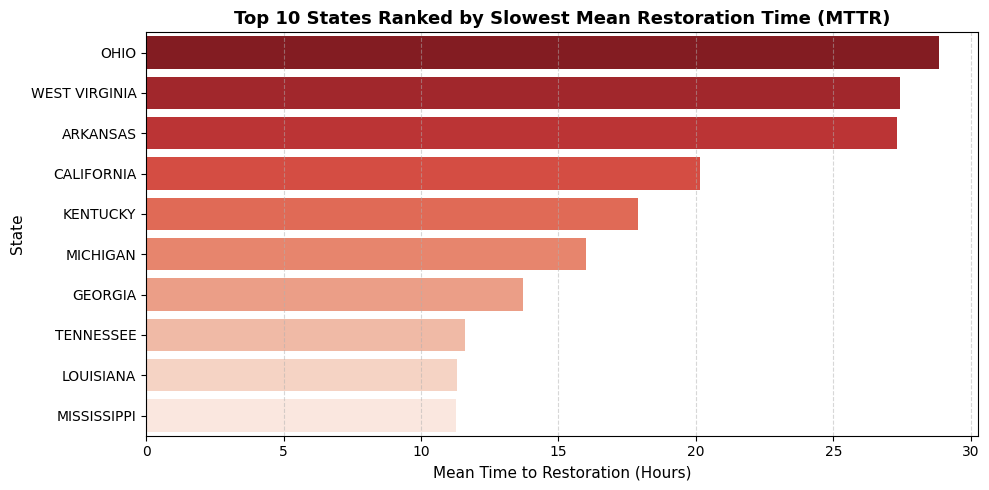

/tmp/ipykernel_1582/1616171432.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_cust_hrs, x='total_customer_hours', y='STATE', palette='Blues_r')


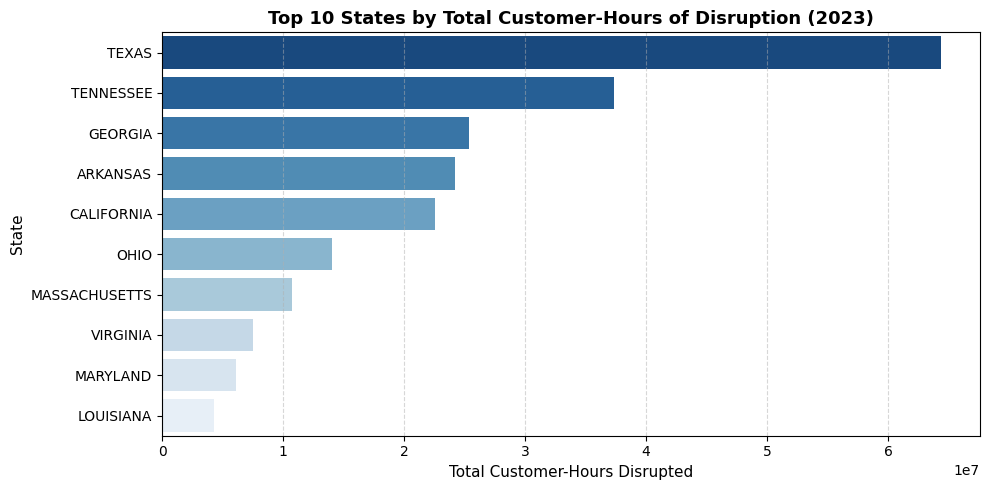

In [12]:
# Aggregate outage impacts by State
state_resilience = clean_events.groupby('STATE').agg(
    total_events=('restoration_time_hrs', 'count'),
    mean_restoration_hrs=('restoration_time_hrs', 'mean'),
    median_restoration_hrs=('restoration_time_hrs', 'median'),
    total_customer_hours=('customer_hours', 'sum'),
    max_peak_customers=('peak_customers', 'max')
).reset_index()
# Filter states with at least 20 recorded events for statistical validity
state_ranked = state_resilience[state_resilience['total_events'] >= 20].sort_values(
    by='mean_restoration_hrs', ascending=False
).reset_index(drop=True)
print("--- TOP 10 STATES WITH SLOWEST RESTORATION (Highest CIP Investment Need) ---")
display(state_ranked.head(10))
# Visualizing Top 10 Vulnerable States by MTTR
plt.figure(figsize=(10, 5))
top10_states = state_ranked.head(10)
sns.barplot(data=top10_states, x='mean_restoration_hrs', y='STATE', palette='Reds_r')
plt.title("Top 10 States Ranked by Slowest Mean Restoration Time (MTTR)", fontsize=13, fontweight='bold')
plt.xlabel("Mean Time to Restoration (Hours)", fontsize=11)
plt.ylabel("State", fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
# Visualizing Total Customer Hours by State
plt.figure(figsize=(10, 5))
top10_cust_hrs = state_ranked.sort_values(by='total_customer_hours', ascending=False).head(10)
sns.barplot(data=top10_cust_hrs, x='total_customer_hours', y='STATE', palette='Blues_r')
plt.title("Top 10 States by Total Customer-Hours of Disruption (2023)", fontsize=13, fontweight='bold')
plt.xlabel("Total Customer-Hours Disrupted", fontsize=11)
plt.ylabel("State", fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1582/440238713.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1582/440238713.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1582/440238713.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


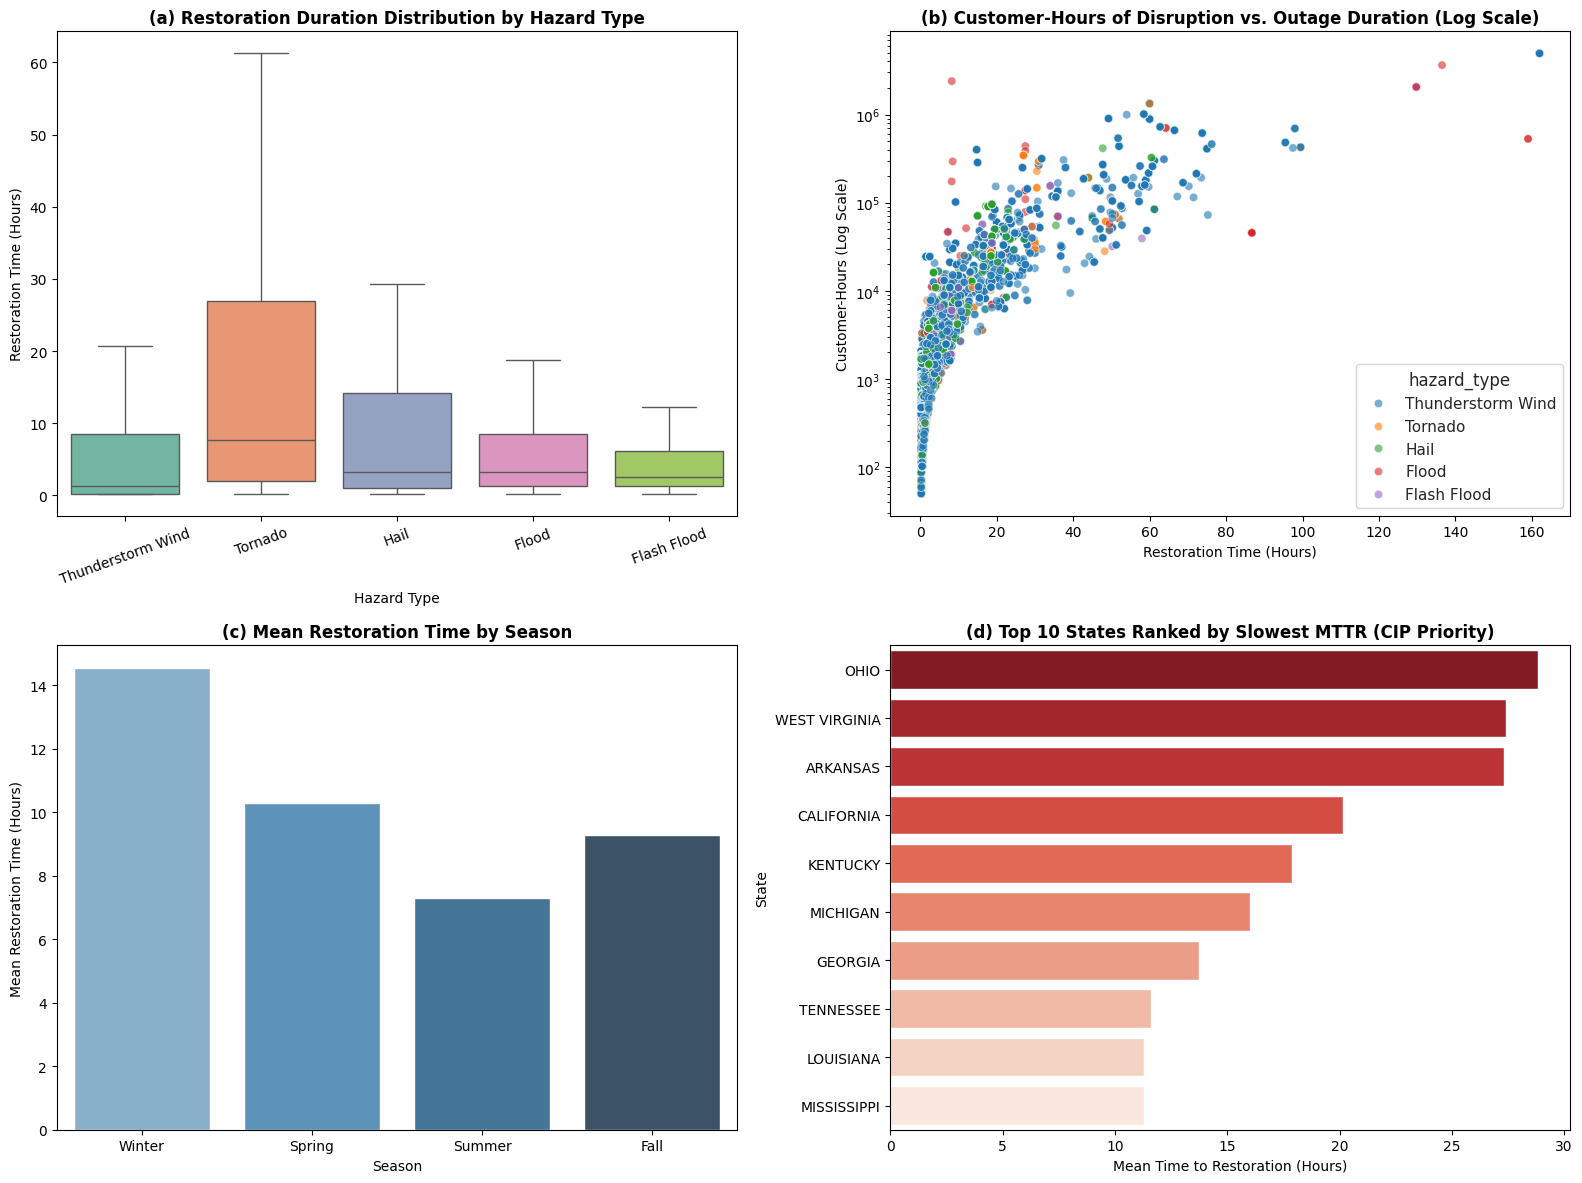


All tables and high-resolution figures saved to: /content/project_results
Downloadable ZIP file created at: /content/Project_Results_Deliverables.zip
Run the next line to download all your results to your computer:
from google.colab import files; files.download('/content/Project_Results_Deliverables.zip')


In [13]:
import os
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns
# Create an export directory
export_dir = "/content/project_results"
os.makedirs(export_dir, exist_ok=True)
# 1. Multi-panel Overview Figure for the Paper
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.set_theme(style="whitegrid")
# Panel A: Restoration Time Distribution by Hazard Type (Violin/Box)
sns.boxplot(
    data=analysis_df,
    x='hazard_type',
    y='restoration_time_hrs',
    palette='Set2',
    ax=axes[0, 0],
    showfliers=False
)
axes[0, 0].set_title("(a) Restoration Duration Distribution by Hazard Type", fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel("Hazard Type", fontsize=10)
axes[0, 0].set_ylabel("Restoration Time (Hours)", fontsize=10)
axes[0, 0].tick_params(axis='x', rotation=20)
# Panel B: Customer-Hours of Disruption vs. Restoration Time (Scatter / Density)
sns.scatterplot(
    data=analysis_df,
    x='restoration_time_hrs',
    y='customer_hours',
    hue='hazard_type',
    alpha=0.6,
    palette='tab10',
    ax=axes[0, 1]
)
axes[0, 1].set_yscale('log')
axes[0, 1].set_title("(b) Customer-Hours of Disruption vs. Outage Duration (Log Scale)", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("Restoration Time (Hours)", fontsize=10)
axes[0, 1].set_ylabel("Customer-Hours (Log Scale)", fontsize=10)
# Panel C: Seasonal Impact on Average Restoration Speed
season_order = ['Winter', 'Spring', 'Summer', 'Fall']
sns.barplot(
    data=analysis_df,
    x='season',
    y='restoration_time_hrs',
    order=[s for s in season_order if s in analysis_df['season'].unique()],
    palette='Blues_d',
    errorbar=None,
    ax=axes[1, 0]
)
axes[1, 0].set_title("(c) Mean Restoration Time by Season", fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel("Season", fontsize=10)
axes[1, 0].set_ylabel("Mean Restoration Time (Hours)", fontsize=10)
# Panel D: Top 10 Most Vulnerable States (Mean MTTR)
top10_states = state_ranked.head(10)
sns.barplot(
    data=top10_states,
    x='mean_restoration_hrs',
    y='STATE',
    palette='Reds_r',
    ax=axes[1, 1]
)
axes[1, 1].set_title("(d) Top 10 States Ranked by Slowest MTTR (CIP Priority)", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("Mean Time to Restoration (Hours)", fontsize=10)
axes[1, 1].set_ylabel("State", fontsize=10)
plt.tight_layout()
fig_path = os.path.join(export_dir, "figure_comprehensive_resilience_analysis.png")
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
# 2. Save Tables to CSV
weibull_df.to_csv(os.path.join(export_dir, "table_weibull_reliability_parameters.csv"), index=False)
state_ranked.to_csv(os.path.join(export_dir, "table_state_resilience_rankings.csv"), index=False)
cph.summary.to_csv(os.path.join(export_dir, "table_cox_regression_summary.csv"))
# 3. Create a ZIP archive of all deliverables
zip_path = "/content/Project_Results_Deliverables.zip"
with zipfile.ZipFile(zip_path, 'w') as zipf:
    for root, _, files in os.walk(export_dir):
        for f in files:
            zipf.write(os.path.join(root, f), arcname=f)
print(f"\nAll tables and high-resolution figures saved to: {export_dir}")
print(f"Downloadable ZIP file created at: {zip_path}")
print("Run the next line to download all your results to your computer:")
print("from google.colab import files; files.download('/content/Project_Results_Deliverables.zip')")

In [14]:
import requests
import json
print("Querying OpenFEMA API for 2023 disaster declarations...")
# Query OpenFEMA API v2 for 2023 declarations
url = "https://www.fema.gov/api/open/v2/DisasterDeclarationsSummaries?$filter=fyDeclared eq 2023&$top=1000"
response = requests.get(url)
if response.status_code == 200:
    fema_data = response.json().get('DisasterDeclarationsSummaries', [])
    fema_df = pd.DataFrame(fema_data)

    # Pad FIPS codes (2-digit state + 3-digit county)
    if 'fipsStateCode' in fema_df.columns and 'fipsCountyCode' in fema_df.columns:
        fema_df['fips'] = (
            fema_df['fipsStateCode'].astype(str).str.zfill(2) +
            fema_df['fipsCountyCode'].astype(str).str.zfill(3)
        )
        fema_df['incidentBeginDate'] = pd.to_datetime(fema_df['incidentBeginDate'], errors='coerce')

        # Count declarations matching counties with outages
        declared_fips = set(fema_df['fips'].unique())
        outage_fips = set(clean_events['fips'].unique())
        overlap_fips = outage_fips.intersection(declared_fips)

        print(f"Total 2023 FEMA declarations fetched: {len(fema_df):,}")
        print(f"Counties in your outage study that received a federal FEMA declaration: {len(overlap_fips):,} ({len(overlap_fips)/len(outage_fips)*100:.1f}%)")

        # Compare MTTR: Declared vs Non-declared counties
        clean_events['fema_declared'] = clean_events['fips'].isin(declared_fips)
        fema_comparison = clean_events.groupby('fema_declared').agg(
            outage_count=('restoration_time_hrs', 'count'),
            mean_mttr_hrs=('restoration_time_hrs', 'mean'),
            median_mttr_hrs=('restoration_time_hrs', 'median'),
            avg_customer_hours=('customer_hours', 'mean')
        ).reset_index()

        fema_comparison['fema_status'] = fema_comparison['fema_declared'].map({True: 'FEMA Declared County', False: 'Non-Declared County'})
        print("\n--- Outage Severity: FEMA Declared vs Non-Declared Counties ---")
        display(fema_comparison[['fema_status', 'outage_count', 'mean_mttr_hrs', 'median_mttr_hrs', 'avg_customer_hours']])
else:
    print(f"Could not connect to OpenFEMA API (Status {response.status_code}).")

Querying OpenFEMA API for 2023 disaster declarations...
Total 2023 FEMA declarations fetched: 1,000
Counties in your outage study that received a federal FEMA declaration: 182 (27.3%)

--- Outage Severity: FEMA Declared vs Non-Declared Counties ---


,fema_status,outage_count,mean_mttr_hrs,median_mttr_hrs,avg_customer_hours
0,Non-Declared County,4494,8.073264,1.25,29021.547285
1,FEMA Declared County,1312,11.487614,3.75,79809.885290
